In [24]:
import os
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

info_path = "../data/info_participants.xlsx"
OUTPUT_PATH = "model_assets/model_1/"
os.makedirs(OUTPUT_PATH, exist_ok=True)

processed_path = "../data/processed/"
os.makedirs(processed_path, exist_ok=True)

RANDOM_SEED = 42
SAMPLE_SEED = 6420

np.random.seed(RANDOM_SEED)
rng = np.random.default_rng(RANDOM_SEED)

PROCESSED = pathlib.Path("../data/processed/modeling_df.parquet")
REFERENCE = pathlib.Path("../data/reference/modeling_df.parquet")

if PROCESSED.exists():
    modeling_parquet = PROCESSED
else:
    print(
        "[warning] data/processed/modeling_df.parquet not found — "
        "falling back to committed frozen reference at data/reference/. "
        "Run bin/build.sh for the fresh pipeline output."
    )
    modeling_parquet = REFERENCE

[warning] data/processed/modeling_df.parquet not found — falling back to committed frozen reference at data/reference/. Run bin/build.sh for the fresh pipeline output.


# Model 1 - Fully Pooled

- Baseline model
- One grand mean
- two speed offsets
- one observation-noise scale 
- No subject structure, no demographic predictors

### Outcome:
- cadence_error
### Per trial:
- spm (strikes per minute)
- continuous
- two-sided (signed)
- Pelvis IMU - force-plate cadence

### Likelihood:
- Fit under Normal first. 
- If the cumulative PPC fails, escalate to Student-t.
- If the Student-t PPC still fails, escalate to skew-t.
- The PPC-pass likelihood propagates to Models 2-4. 


## Load data, build modeling frame
- Load modeling_df.parquet
- Filter to modeling_include==True

In [2]:
df_all = pd.read_parquet(modeling_parquet)
df = df_all[df_all["modeling_include"]].copy()

print('Cadence Error Summary')
print(df["cadence_error"].describe().round(2))
# Expected Trials: 2781
assert len(df) == 2781, f"Expected 2781 trials, got {len(df)}"
# Expected subjects: 47
assert df["subject_id"].nunique() == 47, f"Expected 47 subjects, got {df['subject_id'].nunique()}"
# assert cadence error is not null on any trials (validated during EDA)
assert df["cadence_error"].isnull().sum() == 0, "cadence_error contains null values"


Cadence Error Summary
count    2781.00
mean       -5.52
std        11.22
min       -74.28
25%        -7.09
50%        -2.96
75%        -0.40
max        33.57
Name: cadence_error, dtype: float64


## Build coordinates, indices, and speed dummies
- Using pd.Categorical so that category ordering is pinned by `coords`
- `subject` : positional index into `dims="subject"`
- `sex` : `F` is reliably index 0 - in subsequent models, we will use sex as a demographic variable
- This is not relevant in Model 1, but will be in later models

In [3]:
# pin category ordering for stable idxs across models and runs
subject_ids = sorted(df['subject_id'].unique())
coords = {
    'subject': subject_ids,
    'sex': ['F', 'M'],
    'speed_nonref': ['slow','fast'],
    'obs': np.arange(len(df))
}

# trial level idx into subject (used by models 2-4)
subject_idx = pd.Categorical(
    df['subject_id'],
    categories=coords['subject']
    ).codes

# subject level idx into sex (used by models 3-4)
subjects_df = (
    df[['subject_id', 'sex']]
    .drop_duplicates()
    .set_index('subject_id')
    .loc[coords['subject']]
    .reset_index()
)
sex_of_subject_idx = pd.Categorical(
    subjects_df['sex'],
    categories=coords['sex']
).codes

# speed dummies: comf (comfortable) is the referene level, we are dropping this
# PyMC.Data will handle this, but I'm casting to a float for consistency/ best practice.
speed_dummies = pd.get_dummies(df['speed'])
slow_dummy = speed_dummies['slow'].to_numpy().astype(float)
fast_dummy = speed_dummies['fast'].to_numpy().astype(float)

# Outcome
cadence_error = df['cadence_error'].to_numpy()

# Sanity checks
assert len(subject_idx) == len(df)
assert subject_idx.min() == 0 and subject_idx.max() == 46
assert len(sex_of_subject_idx) == 47
assert sex_of_subject_idx.sum() == 30, "Expected 30 M subjects (sex=1)"
assert slow_dummy.sum() + fast_dummy.sum() + (df["speed"] == "comf").sum() == len(df)

print(f"coords['subject']: {len(coords['subject'])} subjects, first 3 = {coords['subject'][:3]}")
print(f"subject_idx:       shape {subject_idx.shape}, range [{subject_idx.min()}, {subject_idx.max()}]")
print(f"sex counts (F, M): ({(sex_of_subject_idx == 0).sum()}, {(sex_of_subject_idx == 1).sum()})")
print(f"speed counts:      comf={(df['speed']=='comf').sum()}, slow={int(slow_dummy.sum())}, fast={int(fast_dummy.sum())}")

coords['subject']: 47 subjects, first 3 = ['01', '02', '03']
subject_idx:       shape (2781,), range [0, 46]
sex counts (F, M): (17, 30)
speed counts:      comf=933, slow=928, fast=920


## Model 1: Fully pooled, Normal 

### Priors
Weakly informative priors:
- Center at 0 (best guess for bias/ error is none, somewhat like a null hypothesis)
- SD of 10, says 95% of our prior belief is that alpha lives in +/- 20 spm.
- Sigma, not tau. Parameterizing Normal with standard deviation instead of precision (tau = 1/sigma^2).
    - Sigma is better for HalfNormal, tau is only used in BUGS standard. 

### Likelihood
- `cadence_error[i] ~ Normal(mu[i], sigma_obs)`
    - +/- 20 spm of grand-mean bias would be a 15-20% algorithm error. Rules out nonesense. 
- `mu[i] = alpha + beta_slow * slow[i] + beta_fast * fast[i]`
    - slow/fast speed levels are mutually exclusive indicators.
    - when both are zero the trial is at 'comfortable' speed (the reference).
    - `comf`: mu = alpha + beta_slow * 0 + beta_fast * 0 = alpha
    - `slow`: mu = alpha + beta_slow * 1 + beta_fast * 0 = alpha + beta_slow
    - `fast`: mu = alpha + beta_slow * 0 + beta_fast * 1 = alpha + beta_fast

### Specific Prior Distributions 
- `alpha ~ Normal(0,10)`
    - expected cadence error at comf, the reference level
    - center at 0, SD of 10
- `beta_slow ~ Normal(0,5)`
    - mean shift from `comf` to `slow`
    - center at 0, SD of 5
- `beta_fast ~ Normal(0,5)`
    - mean shift from `comf` to `fast`
    - center at 0, SD of 5
- `sigma_obs ~ HalfNormal(10)`
    - expected observation noise
    - scale parameter 10; 95% prior mass on sigma below ~20 spm
    - HalfNormal is a Normal(0, 10) with the negative half removed and density doubled; mode at 0, not mean (mean of HalfNormal(10) is ~8, SD is ~6)
    - EDA trial-level SD is 11.2 spm, so this prior is loose but in the right neighborhood

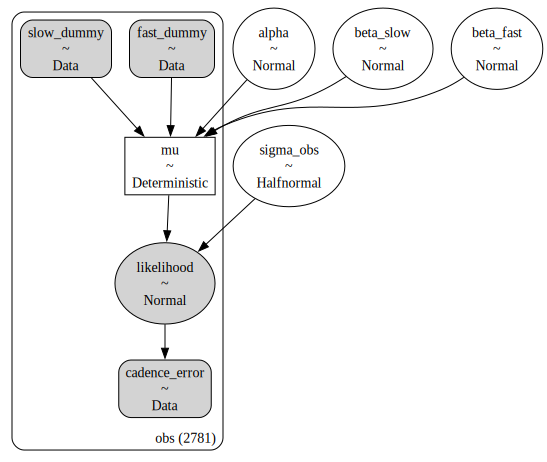

In [4]:
with pm.Model(coords=coords) as model_1:

    # data
    slow = pm.Data('slow_dummy', slow_dummy, dims='obs')
    fast = pm.Data('fast_dummy', fast_dummy, dims='obs')
    y = pm.Data('cadence_error', cadence_error, dims='obs')

    #priors
    alpha = pm.Normal('alpha', mu=0, sigma=10)
    beta_slow = pm.Normal('beta_slow', mu=0, sigma=5)
    beta_fast = pm.Normal('beta_fast', mu=0, sigma=5)
    sigma_obs = pm.HalfNormal('sigma_obs', sigma=10)

    mu = pm.Deterministic(
        'mu',
        alpha + beta_slow * slow + beta_fast * fast,
        dims='obs'
    )

    # likelihood
    pm.Normal('likelihood', mu=mu, sigma=sigma_obs, observed=y, dims='obs')

_dag = pm.model_to_graphviz(model_1)
_dag.render(f"{OUTPUT_PATH}model_1_dag", format="png", cleanup=True)
_dag


Sampling: [alpha, beta_fast, beta_slow, likelihood, sigma_obs]


n = 1390500
mean 0.3, sd 14.6
95%: [-28.3, 29.3]
99%: [-40.8, 41.7]
min/max: -107.3, 113.5
frac |x| > 100: 0.0000


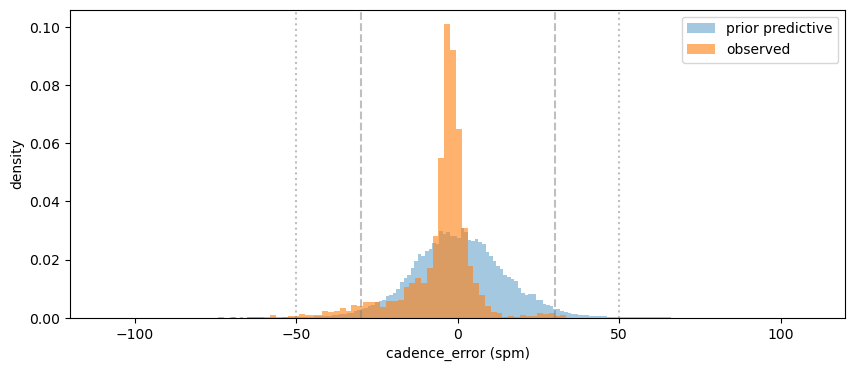

In [5]:
# Prior Predictive Check

with model_1:
    idata_model_1 = pm.sample_prior_predictive(draws=500, random_seed=SAMPLE_SEED)
prior_pred = idata_model_1.prior_predictive['likelihood'].values.flatten()

print(f"n = {len(prior_pred)}")
print(f"mean {prior_pred.mean():.1f}, sd {prior_pred.std():.1f}")
print(f"95%: [{np.percentile(prior_pred, 2.5):.1f}, {np.percentile(prior_pred, 97.5):.1f}]")
print(f"99%: [{np.percentile(prior_pred, 0.5):.1f}, {np.percentile(prior_pred, 99.5):.1f}]")
print(f"min/max: {prior_pred.min():.1f}, {prior_pred.max():.1f}")
print(f"frac |x| > 100: {np.mean(np.abs(prior_pred) > 100):.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(prior_pred, bins=200, density=True, alpha=0.4, label="prior predictive", color="C0")
ax.hist(cadence_error, bins=60, density=True, alpha=0.6, label="observed", color="C1")
for x in (-30, 30):
    ax.axvline(x, ls="--", color="grey", alpha=0.5)
for x in (-50, 50):
    ax.axvline(x, ls=":", color="grey", alpha=0.5)
ax.set_xlabel("cadence_error (spm)")
ax.set_ylabel("density")
ax.set_xlim(-120, 120)
ax.legend()
plt.show()

- 95% within +/- 29 spm
- 99% within +/- 42 spm
- negligible mass beyond +/- 100. 
- Prior covers the observed distribution
- Left tail is heavier than the prior

In [6]:
with model_1:
    idata_model_1 = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        target_accept=0.9,
        random_seed=SAMPLE_SEED,
        idata_kwargs={"log_likelihood": True}
    )
    pm.sample_posterior_predictive(
        idata_model_1,
        extend_inferencedata=True,
        random_seed=SAMPLE_SEED
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_slow, beta_fast, sigma_obs]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 2 seconds.
Sampling: [likelihood]


Output()

## Convergence Diagnostics

- r_hat < 1.01 for every param
- ESS bulk > 400 for every param
- ESS tail > 400 for every param
- Zero divergences!!! 

In [7]:
az.summary(idata_model_1, var_names=["alpha", "beta_slow", "beta_fast", "sigma_obs"], hdi_prob=0.95).round(3)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-4.568,0.367,-5.287,-3.862,0.006,0.005,3469.0,4485.0,1.0
beta_slow,-1.106,0.519,-2.085,-0.071,0.009,0.006,3693.0,4544.0,1.0
beta_fast,-1.750,0.516,-2.753,-0.770,0.008,0.006,4050.0,5140.0,1.0
sigma_obs,11.209,0.150,10.919,11.502,0.002,0.002,6262.0,5080.0,1.0


- r_hat < 1.01 for all parameters: `passed`
- ess_bulk > 400 for all parameters: `passed`
- ess_tail > 400 for all parameters: `passed`
- Zero divergences: `passed`
- MCSE_SD (monte carlo standard error of the mean) < 0.01 for all parameters: `passed`

### Notes:
- beta_slow under 95% HDI upper bound is very close to zero
    - under fully pooled model, slow-vs-comf difference is barely distinguishible from zero at 95% HDI
- beta_fast under 95% HDI is slightly more negative, excluding zero a little more comfortably 
    - this suggests that under a fully pooled model, there is a small but detectable difference between fast and comfortable speeds

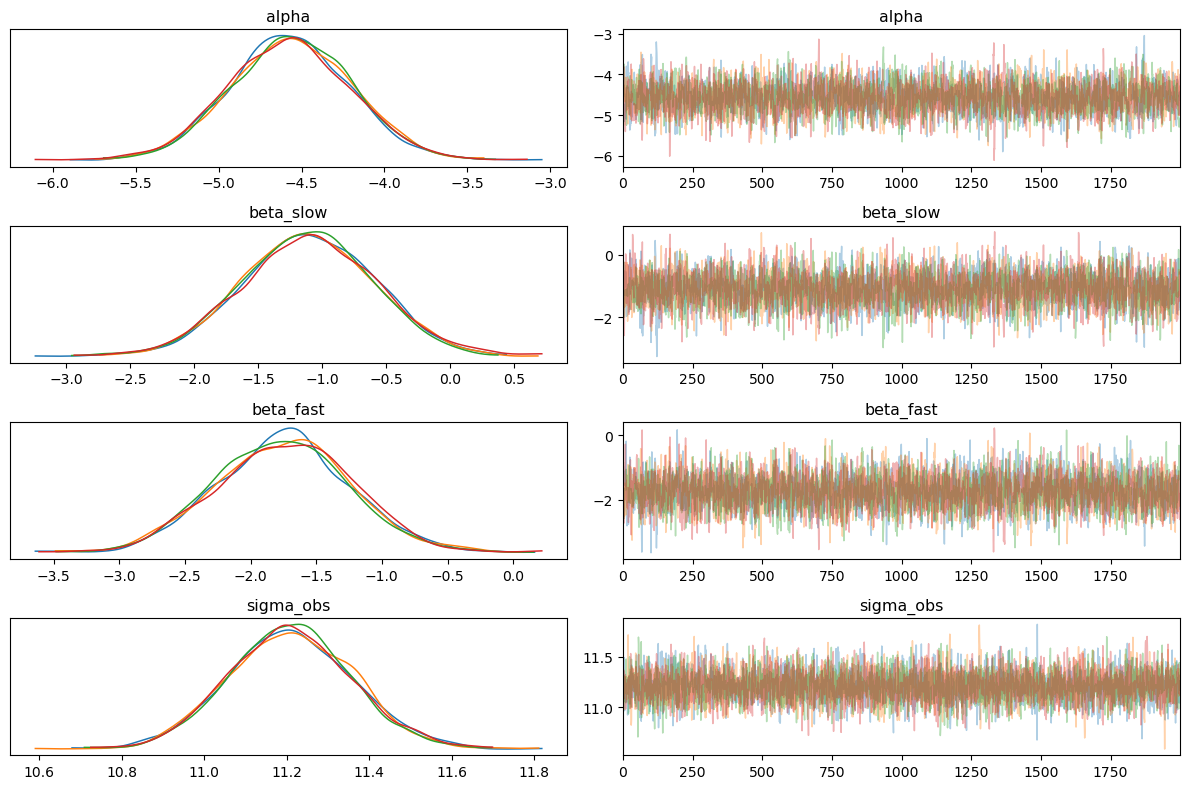

In [8]:
az.plot_trace(idata_model_1, var_names=["alpha", "beta_slow", "beta_fast", "sigma_obs"], compact=False)
plt.tight_layout()
plt.gcf().savefig(f"{OUTPUT_PATH}model_1_trace.png", dpi=200, bbox_inches="tight")
plt.show()

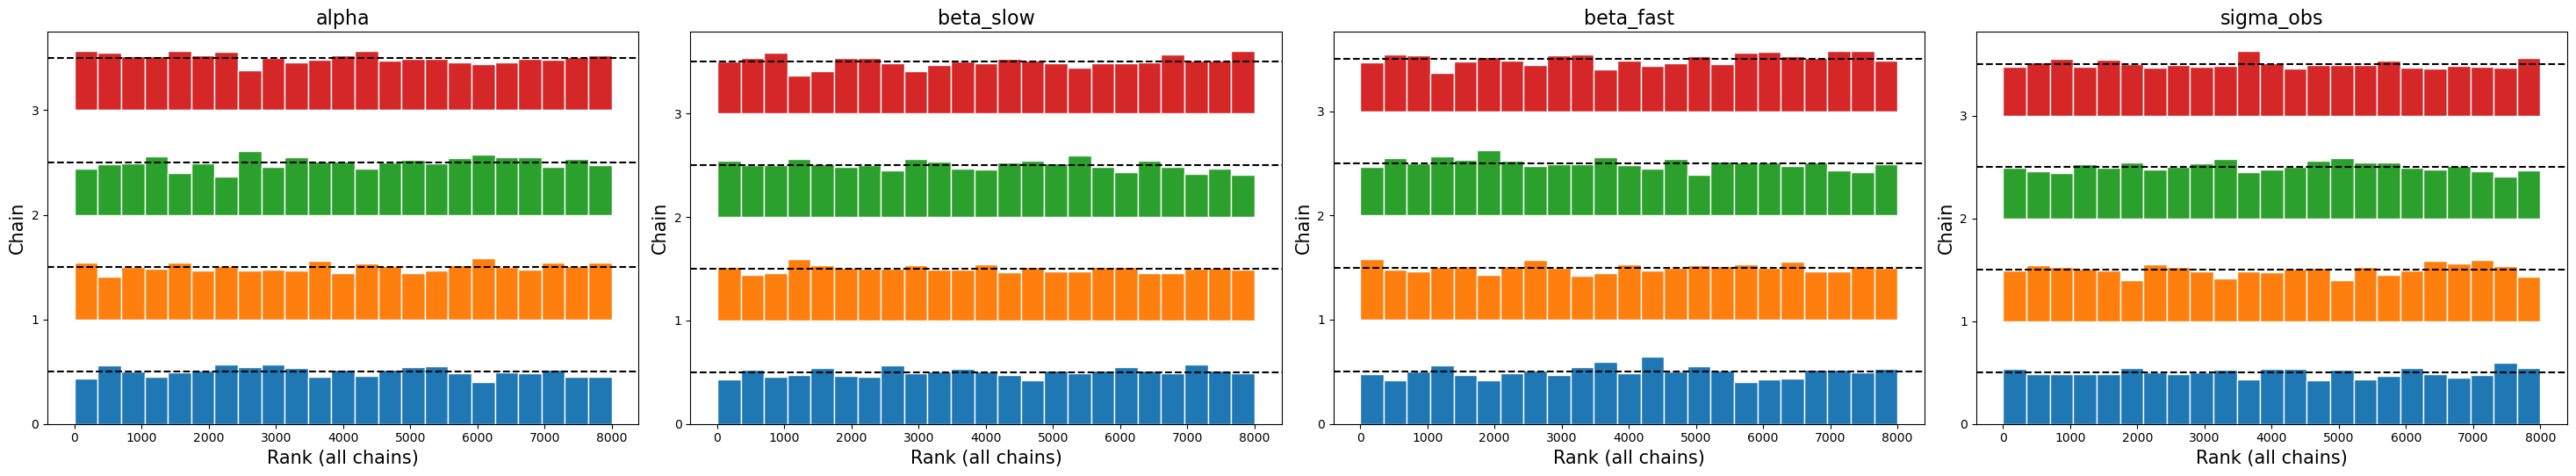

In [9]:
az.plot_rank(idata_model_1, var_names=["alpha", "beta_slow", "beta_fast", "sigma_obs"])
plt.tight_layout()
plt.gcf().savefig(f"{OUTPUT_PATH}model_1_rank.png", dpi=200, bbox_inches="tight")
plt.show()

## Posterior Predictive Check

- Convergence diagnostics look good, the MCMC worked
- This does not provide insight into whether the model is good
- Normal likelihoods can converge nicely and still be the wrong fit for the data

/var/folders/n9/8tgrbsbx61n9yzm2f0wrchh00000gp/T/ipykernel_77944/2618076506.py:5: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(f"{OUTPUT_PATH}model_1_ppc.png", dpi=200, bbox_inches="tight")
/Users/mgriffith/miniconda3/envs/wearable-calibration-bayes/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


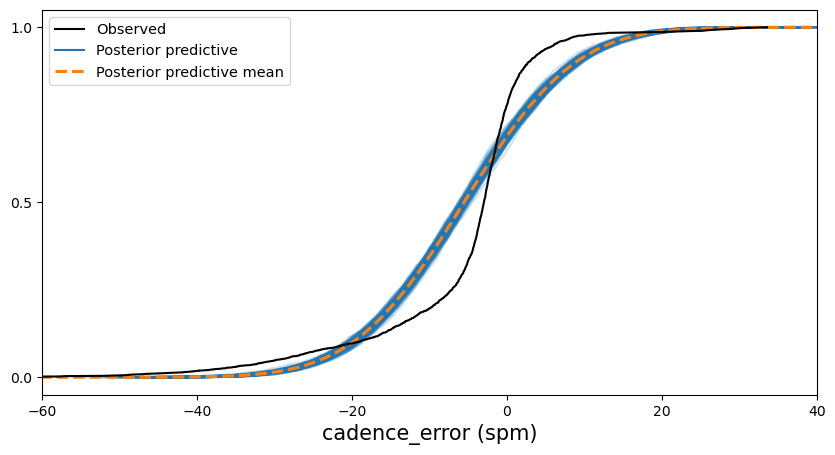

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
az.plot_ppc(idata_model_1, kind="cumulative", num_pp_samples=200, ax=ax)
ax.set_xlabel("cadence_error (spm)")
ax.set_xlim(-60, 40)
fig.savefig(f"{OUTPUT_PATH}model_1_ppc.png", dpi=200, bbox_inches="tight")
plt.show()

- Observed ECDF (black) is steeper through the middle and flatter in both tails than our posterior predictive ECDF (blue).
- excess kurtosis: classic signature of a distribution that is heavy tailed, moreso than a normal.
- at cadence_error = -20 spm, observed ECDF is at ~0.1, posterior predictive ECDF is ~0.2 
    - model overpredicts near left tail 
- at cadence error -5 spm: observed ECDF is at ~0.5, posterior predictive ECDF is ~0.45
    - model predicts 45% of trials below -5, the data has 55%.
    - model underpredicts mass near center
- at cadence error +5 spm: observed ECDF is at ~0.95, posterior predictive ECDF is ~0.8 
    - model underpredicts mass near right tail
- At cadence error -40 spm: Observed ECDF is ~0.03, posterior predictive ECDF is basically 0 
    - model underpredicts mass in the extreme left tail

## Model 1t: Fully pooled, Student-t likelihood

### Priors
Weakly informative priors:
- Center at 0 (best guess for bias/ error is none, somewhat like a null hypothesis)
- SD of 10, says 95% of our prior belief is that alpha lives in +/- 20 spm.
- Sigma, not tau. Parameterizing with standard deviation instead of precision (tau = 1/sigma^2).
    - Sigma is better for HalfNormal, tau is only used in BUGS standard.

### Likelihood
- `cadence_error[i] ~ StudentT(nu, mu[i], sigma_obs)`
    - Student-t adds `nu` (degrees of freedom) controlling tail thickness. Low nu = fat tails, high nu -> Normal.
- `mu[i] = alpha + beta_slow * slow[i] + beta_fast * fast[i]`
    - slow/fast speed levels are mutually exclusive indicators.
    - when both are zero the trial is at 'comfortable' speed (the reference).
    - `comf`: mu = alpha + beta_slow * 0 + beta_fast * 0 = alpha
    - `slow`: mu = alpha + beta_slow * 1 + beta_fast * 0 = alpha + beta_slow
    - `fast`: mu = alpha + beta_slow * 0 + beta_fast * 1 = alpha + beta_fast

### Specific Prior Distributions
- `nu ~ Gamma(2, 0.1)`
    - degrees of freedom for the Student-t distribution
    - mean 20, SD ~14
    - puts most prior mass in the 5-40 range
    - `nu < 5` gives very fat tails, `nu >= 30` is close to Normal
- `alpha ~ Normal(0,10)`
    - expected cadence error at comf, the reference level
    - center at 0, SD of 10
    - +/- 20 spm of grand-mean bias would be a 15-20% algorithm error. Rules out nonsense.
- `beta_slow ~ Normal(0,5)`
    - mean shift from `comf` to `slow`
    - center at 0, SD of 5
- `beta_fast ~ Normal(0,5)`
    - mean shift from `comf` to `fast`
    - center at 0, SD of 5
- `sigma_obs ~ HalfNormal(10)`
    - expected observation noise
    - scale parameter 10; 95% prior mass on sigma below ~20 spm
    - HalfNormal is a Normal(0, 10) with the negative half removed and density doubled; mode at 0, not mean (mean of HalfNormal(10) is ~8, SD is ~6)
    - EDA trial-level SD is 11.2 spm, so this prior is loose but in the right neighborhood

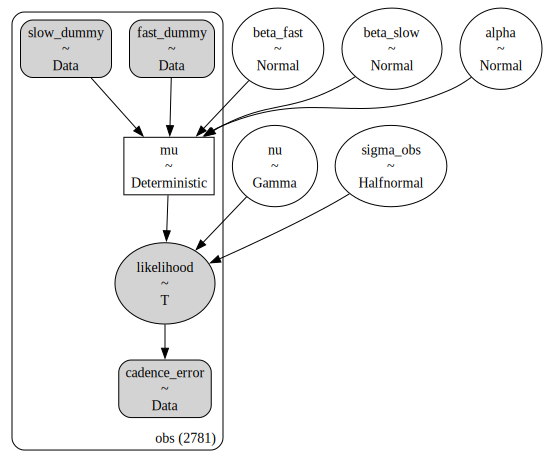

In [11]:
with pm.Model(coords=coords) as model_1t:

    # data
    slow = pm.Data('slow_dummy', slow_dummy, dims='obs')
    fast = pm.Data('fast_dummy', fast_dummy, dims='obs')
    y = pm.Data('cadence_error', cadence_error, dims='obs')

    #priors
    nu = pm.Gamma('nu', alpha=2, beta=0.1)
    alpha = pm.Normal('alpha', mu=0, sigma=10)
    beta_slow = pm.Normal('beta_slow', mu=0, sigma=5)
    beta_fast = pm.Normal('beta_fast', mu=0, sigma=5)
    sigma_obs = pm.HalfNormal('sigma_obs', sigma=10)

    mu = pm.Deterministic(
        'mu',
        alpha + beta_slow * slow + beta_fast * fast,
        dims='obs'
    )

    # likelihood
    pm.StudentT('likelihood', nu=nu, mu=mu, sigma=sigma_obs, observed=y, dims='obs')

_dag = pm.model_to_graphviz(model_1t)
_dag.render(f"{OUTPUT_PATH}model_1t_dag", format="png", cleanup=True)
_dag


Sampling: [alpha, beta_fast, beta_slow, likelihood, nu, sigma_obs]


n = 1390500
mean 0.9, sd 16.1
95%: [-29.4, 31.3]
99%: [-45.9, 48.0]
min/max: -1795.9, 1705.9
frac |x| > 100: 0.0004


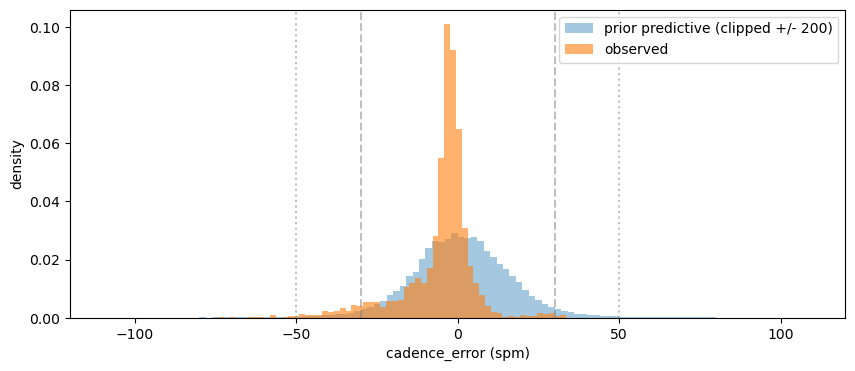

In [12]:
# prior predictive check

with model_1t:
    idata_model_1t = pm.sample_prior_predictive(draws=500, random_seed=SAMPLE_SEED)

prior_pred_t = idata_model_1t.prior_predictive['likelihood'].values.flatten()

print(f"n = {len(prior_pred_t)}")
print(f"mean {prior_pred_t.mean():.1f}, sd {prior_pred_t.std():.1f}")
print(f"95%: [{np.percentile(prior_pred_t, 2.5):.1f}, {np.percentile(prior_pred_t, 97.5):.1f}]")
print(f"99%: [{np.percentile(prior_pred_t, 0.5):.1f}, {np.percentile(prior_pred_t, 99.5):.1f}]")
print(f"min/max: {prior_pred_t.min():.1f}, {prior_pred_t.max():.1f}")
print(f"frac |x| > 100: {np.mean(np.abs(prior_pred_t) > 100):.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
# Clip the extreme tails for plotting — Student-t with low nu can produce
# enormous outliers that wreck histogram axis scaling even though they're
# rare enough to not matter for the pass/fail call.
clipped = np.clip(prior_pred_t, -200, 200)
ax.hist(clipped, bins=200, density=True, alpha=0.4, label="prior predictive (clipped +/- 200)", color="C0")
ax.hist(cadence_error, bins=60, density=True, alpha=0.6, label="observed", color="C1")
for x in (-30, 30):
    ax.axvline(x, ls="--", color="grey", alpha=0.5)
for x in (-50, 50):
    ax.axvline(x, ls=":", color="grey", alpha=0.5)
ax.set_xlabel("cadence_error (spm)")
ax.set_ylabel("density")
ax.set_xlim(-120, 120)
ax.legend()
plt.show()

- 95% within +/- 30 spm
- 99% within +/- 48 spm
- min/max at +/- 1800 (expected fat-tail signature from low `nu` draws)
- 0.04% beyond +/- 100, well within tolerance
- bulk identical to Model 1 prior predictive
- no prior adjustment needed

In [13]:
with model_1t:
    idata_model_1t = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        target_accept=0.9,
        random_seed=SAMPLE_SEED,
        idata_kwargs={"log_likelihood": True},
    )
    pm.sample_posterior_predictive(idata_model_1t, extend_inferencedata=True, random_seed=SAMPLE_SEED)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [nu, alpha, beta_slow, beta_fast, sigma_obs]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 3 seconds.
Sampling: [likelihood]


Output()

In [14]:
az.summary(idata_model_1t, var_names = ['alpha','beta_slow','beta_fast','sigma_obs','nu'], hdi_prob=0.95).round(3)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-2.311,0.128,-2.564,-2.063,0.002,0.001,4858.0,4977.0,1.0
beta_slow,0.732,0.206,0.323,1.127,0.003,0.002,5472.0,5266.0,1.0
beta_fast,-1.413,0.195,-1.790,-1.031,0.003,0.002,5399.0,5529.0,1.0
sigma_obs,3.221,0.103,3.010,3.413,0.001,0.001,5472.0,5783.0,1.0
nu,1.186,0.045,1.103,1.278,0.001,0.000,5618.0,5927.0,1.0


- r_hat < 1.01: `passed`
- ess_bulk > 400: `passed`
- ess_tail > 400: `passed`
- zero divergences: `passed`
- MCSE_SD < 0.01: `passed`

### Notes:
MCMC converged but posterior is weird.

`nu = 1.19`. Cauchy territory. Model wants infinite tails.

Everything else moved:
- `sigma_obs` 11.21 -> 3.22. Noise shoved into tails.
- `alpha` -4.57 -> -2.31. Mechanical: when nu<2 location isn't the mean.
- `beta_slow` flipped sign, -1.11 -> +0.73.

The 133-trial undercount band isn't symmetric tail noise. It's female + slow, subjects 08/47. Student-t fits it by making tails fat enough to swallow it. Treats the audit signal as noise. Not what I want.

Running PPC next.

### Posterior Predictive Checks

Same cumulative ECDF as Model 1. Observed inside the band across [0.05, 0.95] = pass.

Watching for:
1. Does the fat-tail fit actually cover the observed data?
2. Asymmetric miscoverage? Student-t is symmetric. If observed is above the band on one side and below on the other, that's a skew signal and skew-t is next.

/var/folders/n9/8tgrbsbx61n9yzm2f0wrchh00000gp/T/ipykernel_77944/1330672324.py:5: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(f"{OUTPUT_PATH}model_1t_ppc.png", dpi=200, bbox_inches="tight")
/Users/mgriffith/miniconda3/envs/wearable-calibration-bayes/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


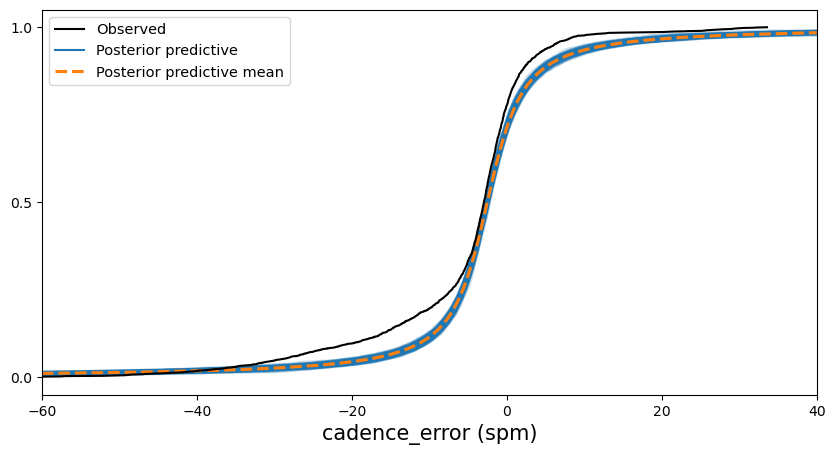

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
az.plot_ppc(idata_model_1t, kind="cumulative", num_pp_samples=200, ax=ax)
ax.set_xlabel("cadence_error (spm)")
ax.set_xlim(-60, 40)
fig.savefig(f"{OUTPUT_PATH}model_1t_ppc.png", dpi=200, bbox_inches="tight")
plt.show()

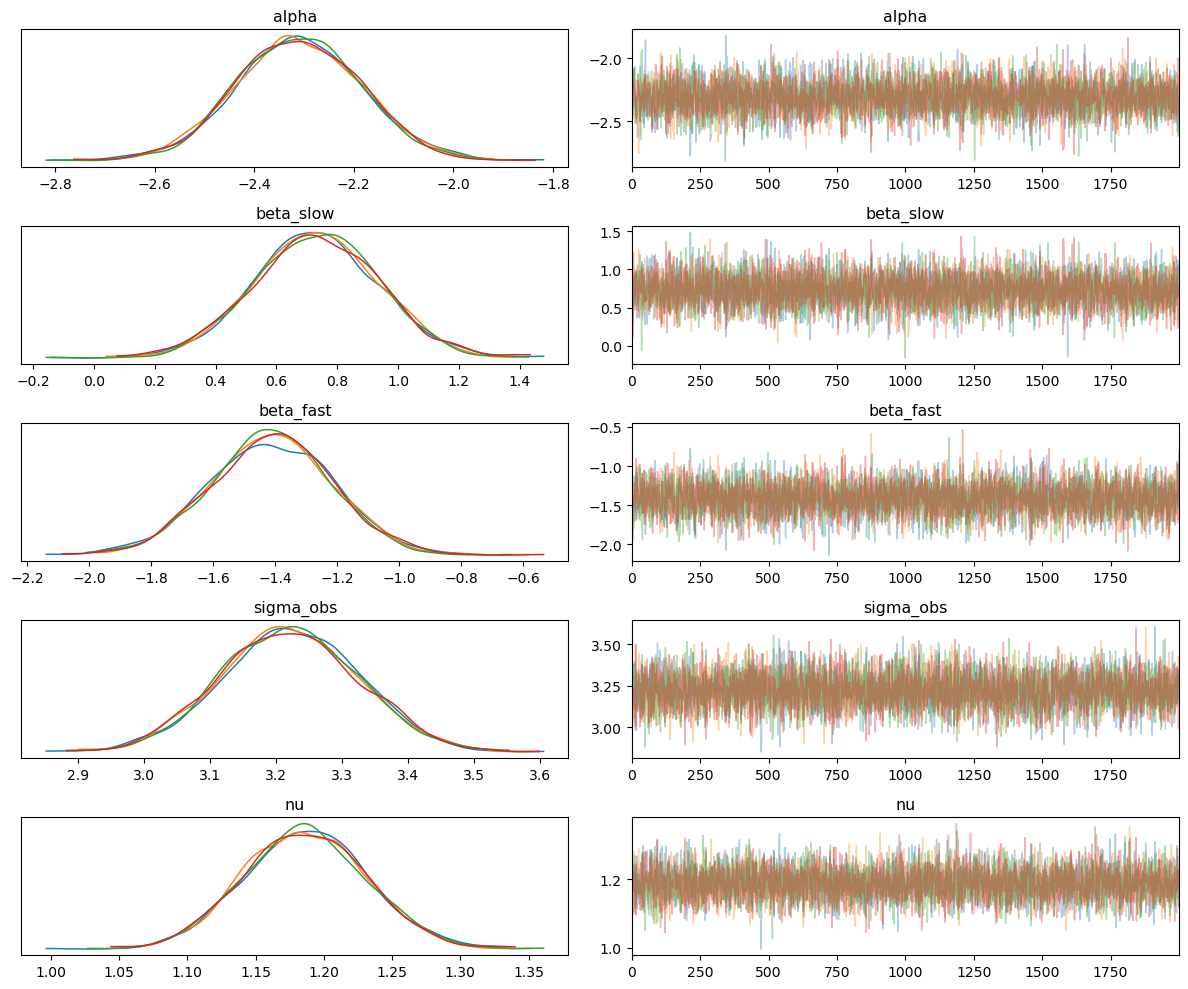

In [16]:
az.plot_trace(idata_model_1t, var_names=["alpha", "beta_slow", "beta_fast", "sigma_obs", "nu"], compact=False)
plt.tight_layout()
plt.gcf().savefig(f"{OUTPUT_PATH}model_1t_trace.png", dpi=200, bbox_inches="tight")
plt.show()

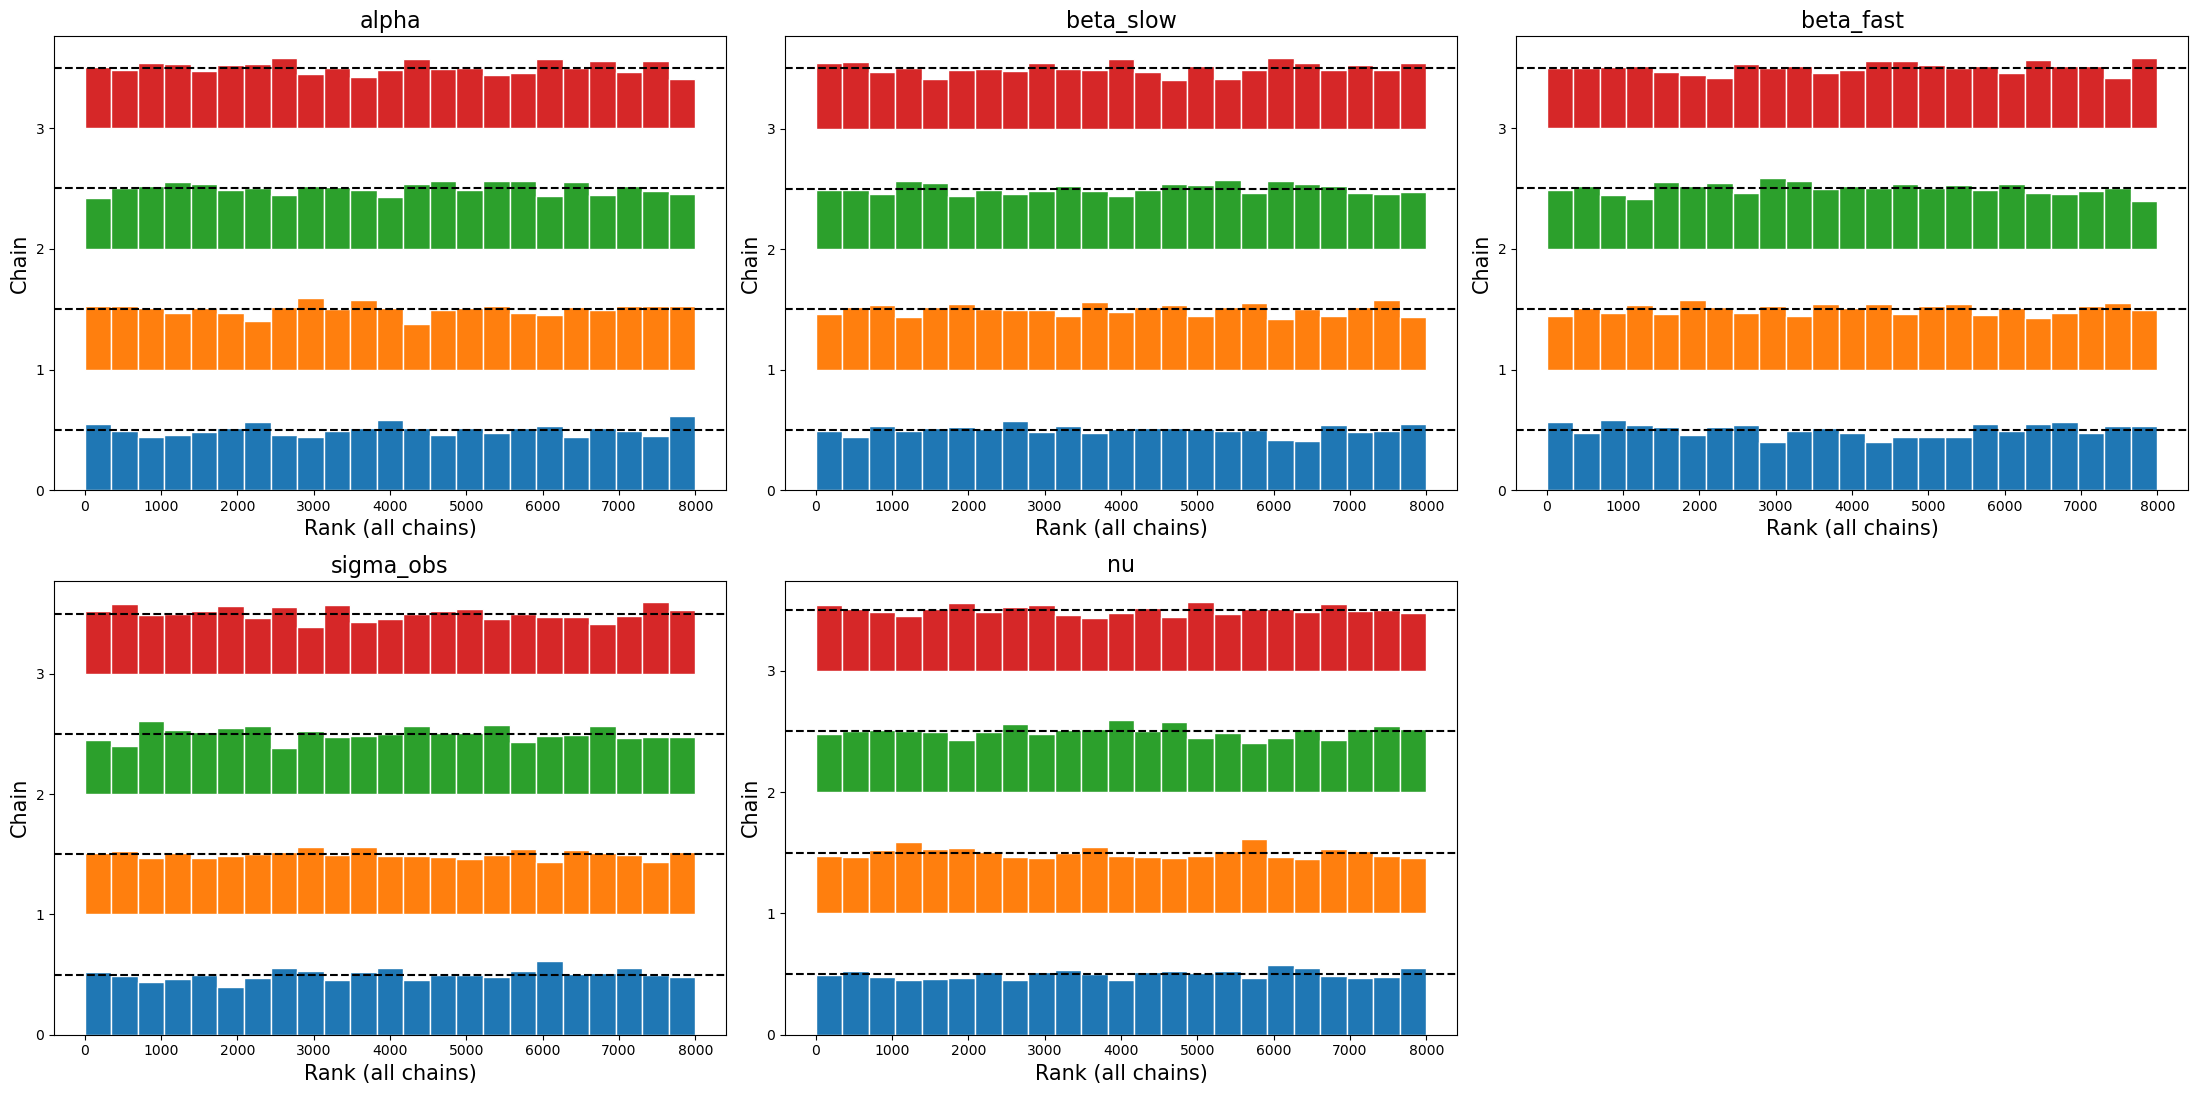

In [17]:
az.plot_rank(idata_model_1t, var_names=["alpha", "beta_slow", "beta_fast", "sigma_obs", "nu"])
plt.tight_layout()
plt.gcf().savefig(f"{OUTPUT_PATH}model_1t_rank.png", dpi=200, bbox_inches="tight")
plt.show()

### PPC: fail

Asymmetric. Observed above the band on both sides.
- Left: data has a longer left tail than Student-t models. 133-trial undercount band still showing.
- Right: model's right tail overshoots what the data actually does. Symmetric fat tails = symmetric overshoot.

Skew-t next.

## Model 1skew: Fully pooled, skew-t likelihood

### Priors
Weakly informative priors:
- Center at 0 (best guess for bias/ error is none, somewhat like a null hypothesis)
- SD of 10, says 95% of our prior belief is that alpha lives in +/- 20 spm.
- Sigma, not tau. Parameterizing with standard deviation instead of precision (tau = 1/sigma^2).
    - Sigma is better for HalfNormal, tau is only used in BUGS standard.

### Likelihood
- `cadence_error[i] ~ SkewStudentT(a, b, mu[i], sigma_obs)`
    - Fernandez-Steel parameterization. Two shape params instead of one `nu`. When a=b, reduces to symmetric Student-t with nu=a+b. a<b gives left skew, a>b gives right skew.
    - Expect a<b in the posterior; data is left-skewed.
- `mu[i] = alpha + beta_slow * slow[i] + beta_fast * fast[i]`
    - slow/fast speed levels are mutually exclusive indicators.
    - when both are zero the trial is at 'comfortable' speed (the reference).
    - `comf`: mu = alpha + beta_slow * 0 + beta_fast * 0 = alpha
    - `slow`: mu = alpha + beta_slow * 1 + beta_fast * 0 = alpha + beta_slow
    - `fast`: mu = alpha + beta_slow * 0 + beta_fast * 1 = alpha + beta_fast

### Specific Prior Distributions
- `a ~ Gamma(2, 0.1)`
    - left-tail shape parameter. Mean 20, SD 14. Positive support.
    - `a + b` plays the role of `nu` in Student-t. Independent Gamma(2, 0.1) priors put the implied `a+b` prior mean at 40, which is more Normal-like than the nu prior we used in Model 1-t. Fine: we already know the data needs fatter tails, and the skew parameter will do some of that work.
- `b ~ Gamma(2, 0.1)`
    - right-tail shape parameter. Same prior as `a`.
- `alpha ~ Normal(0,10)`
    - expected cadence error at comf, the reference level
    - center at 0, SD of 10
- `beta_slow ~ Normal(0,5)`
    - mean shift from `comf` to `slow`
    - center at 0, SD of 5
- `beta_fast ~ Normal(0,5)`
    - mean shift from `comf` to `fast`
    - center at 0, SD of 5
- `sigma_obs ~ HalfNormal(10)`
    - expected observation noise
    - scale parameter 10; 95% prior mass on sigma below ~20 spm
    - HalfNormal is a Normal(0, 10) with the negative half removed and density doubled; mode at 0, not mean (mean of HalfNormal(10) is ~8, SD is ~6)
    - EDA trial-level SD is 11.2 spm, so this prior is loose but in the right neighborhood

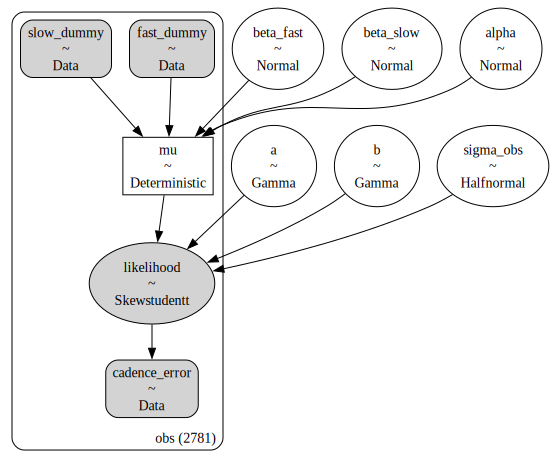

In [18]:
with pm.Model(coords=coords) as model_1skew:

    # data
    slow = pm.Data('slow_dummy', slow_dummy, dims='obs')
    fast = pm.Data('fast_dummy', fast_dummy, dims='obs')
    y = pm.Data('cadence_error', cadence_error, dims='obs')

    #priors
    a = pm.Gamma('a', 2, 0.1)
    b = pm.Gamma('b', 2, 0.1)
    alpha_ = pm.Normal('alpha', mu=0, sigma=10)
    beta_slow = pm.Normal('beta_slow', mu=0, sigma=5)
    beta_fast = pm.Normal('beta_fast', mu=0, sigma=5)
    sigma_obs = pm.HalfNormal('sigma_obs', sigma=10)

    mu = pm.Deterministic(
        'mu',
        alpha_ + beta_slow * slow + beta_fast * fast,
        dims='obs'
    )

    # likelihood
    pm.SkewStudentT('likelihood', a=a, b=b, mu=mu, sigma=sigma_obs, observed=y, dims='obs')

pm.model_to_graphviz(model_1skew)

Sampling: [a, alpha, b, beta_fast, beta_slow, likelihood, sigma_obs]


n = 1390500
mean -2.2, sd 59.2
95%: [-101.5, 95.7]
99%: [-181.2, 158.1]
min/max: -14721.0, 4713.4
frac |x| > 100: 0.0486


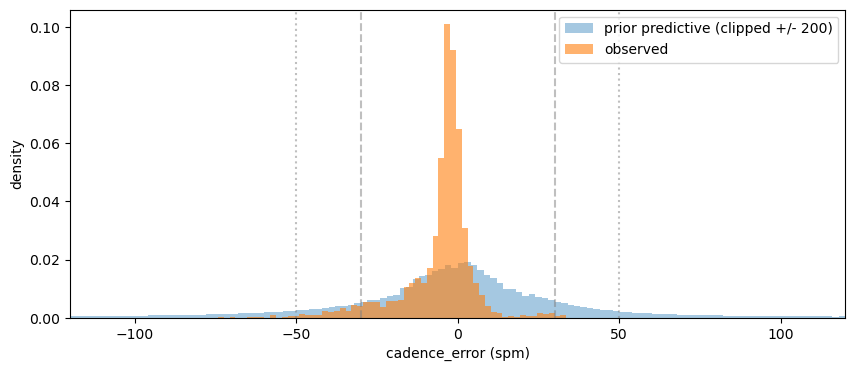

In [19]:
# prior predictive check

with model_1skew:
    idata_model_1skew = pm.sample_prior_predictive(draws=500, random_seed=SAMPLE_SEED)

prior_pred_1skew = idata_model_1skew.prior_predictive['likelihood'].values.flatten()

print(f"n = {len(prior_pred_1skew)}")
print(f"mean {prior_pred_1skew.mean():.1f}, sd {prior_pred_1skew.std():.1f}")
print(f"95%: [{np.percentile(prior_pred_1skew, 2.5):.1f}, {np.percentile(prior_pred_1skew, 97.5):.1f}]")
print(f"99%: [{np.percentile(prior_pred_1skew, 0.5):.1f}, {np.percentile(prior_pred_1skew, 99.5):.1f}]")
print(f"min/max: {prior_pred_1skew.min():.1f}, {prior_pred_1skew.max():.1f}")
print(f"frac |x| > 100: {np.mean(np.abs(prior_pred_1skew) > 100):.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
clipped = np.clip(prior_pred_1skew, -200, 200)
ax.hist(clipped, bins=200, density=True, alpha=0.4, label="prior predictive (clipped +/- 200)", color="C0")
ax.hist(cadence_error, bins=60, density=True, alpha=0.6, label="observed", color="C1")
for x in (-30, 30):
    ax.axvline(x, ls="--", color="grey", alpha=0.5)
for x in (-50, 50):
    ax.axvline(x, ls=":", color="grey", alpha=0.5)
ax.set_xlabel("cadence_error (spm)")
ax.set_ylabel("density")
ax.set_xlim(-120, 120)
ax.legend()
plt.show()


Too wide.

- SD = 59.2 vs 14.6 (Model 1), 16.1 (Model 1-t). 4x the data.
- 95% in +/- 100, target was +/- 30.
- 99% in +/- 180, target was +/- 50.
- 5% beyond +/- 100. Not negligible.
- min/max +/- 15,000. Cauchy tails on both sides at once.

Why: Gamma(2, 0.1) on both a and b means occasionally both are small at the same time. Model 1-t had one nu; Model 1-skew has two tail params and the joint prior hits the corner where both are tiny.

Fix: tighten. Going with Gamma(10, 0.1) on both. Mean 100, SD ~32. Fat-tail range stays reachable, Cauchy corner goes away. a+b implied mean is 200.

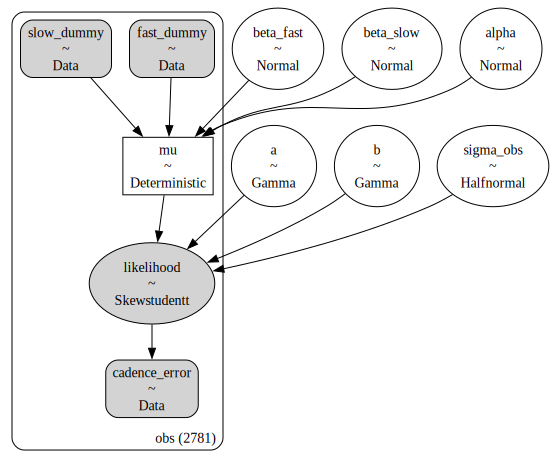

In [20]:
with pm.Model(coords=coords) as model_1skew:

    # data
    slow = pm.Data('slow_dummy', slow_dummy, dims='obs')
    fast = pm.Data('fast_dummy', fast_dummy, dims='obs')
    y = pm.Data('cadence_error', cadence_error, dims='obs')

    #priors
    a = pm.Gamma('a', 10, 0.1)
    b = pm.Gamma('b', 10, 0.1)
    alpha_ = pm.Normal('alpha', mu=0, sigma=10)
    beta_slow = pm.Normal('beta_slow', mu=0, sigma=5)
    beta_fast = pm.Normal('beta_fast', mu=0, sigma=5)
    sigma_obs = pm.HalfNormal('sigma_obs', sigma=10)

    mu = pm.Deterministic(
        'mu',
        alpha_ + beta_slow * slow + beta_fast * fast,
        dims='obs'
    )

    # likelihood
    pm.SkewStudentT('likelihood', a=a, b=b, mu=mu, sigma=sigma_obs, observed=y, dims='obs')

pm.model_to_graphviz(model_1skew)

Sampling: [a, alpha, b, beta_fast, beta_slow, likelihood, sigma_obs]


n = 1390500
mean -1.7, sd 39.3
95%: [-89.3, 77.2]
99%: [-155.9, 140.7]
min/max: -359.8, 355.7
frac |x| > 100: 0.0329


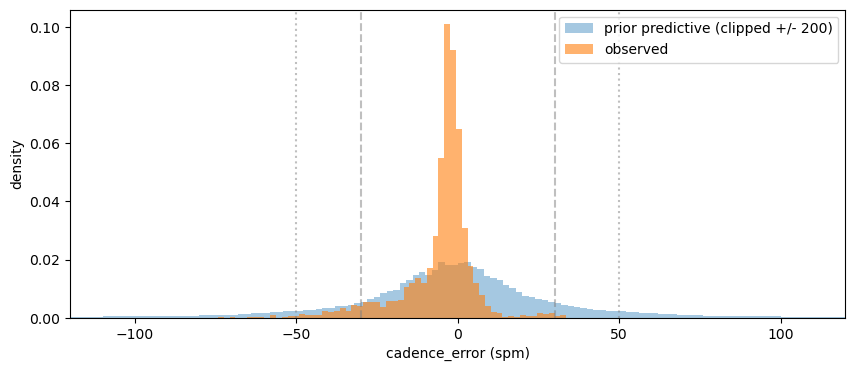

In [21]:
# prior predictive check

with model_1skew:
    idata_model_1skew = pm.sample_prior_predictive(draws=500, random_seed=SAMPLE_SEED)

prior_pred_1skew = idata_model_1skew.prior_predictive['likelihood'].values.flatten()

print(f"n = {len(prior_pred_1skew)}")
print(f"mean {prior_pred_1skew.mean():.1f}, sd {prior_pred_1skew.std():.1f}")
print(f"95%: [{np.percentile(prior_pred_1skew, 2.5):.1f}, {np.percentile(prior_pred_1skew, 97.5):.1f}]")
print(f"99%: [{np.percentile(prior_pred_1skew, 0.5):.1f}, {np.percentile(prior_pred_1skew, 99.5):.1f}]")
print(f"min/max: {prior_pred_1skew.min():.1f}, {prior_pred_1skew.max():.1f}")
print(f"frac |x| > 100: {np.mean(np.abs(prior_pred_1skew) > 100):.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
clipped = np.clip(prior_pred_1skew, -200, 200)
ax.hist(clipped, bins=200, density=True, alpha=0.4, label="prior predictive (clipped +/- 200)", color="C0")
ax.hist(cadence_error, bins=60, density=True, alpha=0.6, label="observed", color="C1")
for x in (-30, 30):
    ax.axvline(x, ls="--", color="grey", alpha=0.5)
for x in (-50, 50):
    ax.axvline(x, ls=":", color="grey", alpha=0.5)
ax.set_xlabel("cadence_error (spm)")
ax.set_ylabel("density")
ax.set_xlim(-120, 120)
ax.legend()
plt.show()


### Skew-t: abandoned

Tried Gamma(2, 0.1) and Gamma(10, 0.1) on (a, b). Prior predictive never tightened enough: SD stayed 40-60, 95% range stayed near +/- 90, 5% of mass beyond +/- 100. Fernandez-Steel (a, b) doesn't regularize cleanly with independent Gammas; reparameterizing to (nu, skew) would work but is outside course scope.

Calling it. Student-t is the Model 1 likelihood decision.

The more interesting question: is the observed asymmetry a distributional feature (needs skew-t) or a structural one (subjects 08 + 47 in F-slow drive most of the left tail)? Model 2 partial pooling will tell us. If subject-level intercepts absorb the skew, Student-t on the likelihood will be fine.

### LOO-CV: Model 1 escalation chain

- Compare Normal vs Student-t on leave-one-out log-likelihood. 
- Higher elpd_loo = better out-of-sample predictive fit. 
- Student-t should win; by how much tells us whether the kurtosis/skew mismatch actually mattered for predictive quality.

In [22]:
loo_model_1  = az.loo(idata_model_1,  pointwise=True)
loo_model_1t = az.loo(idata_model_1t, pointwise=True)

comparison = az.compare({"Model 1 (Normal)": idata_model_1, "Model 1-t (Student-t)": idata_model_1t}, ic="loo")
print(comparison)

                       rank      elpd_loo     p_loo   elpd_diff    weight  \
Model 1-t (Student-t)     0  -9797.784971  4.506263    0.000000  0.866721   
Model 1 (Normal)          1 -10669.754559  6.524155  871.969588  0.133279   

                              se        dse  warning scale  
Model 1-t (Student-t)  78.656602   0.000000    False   log  
Model 1 (Normal)       70.340772  52.888415    False   log  


### LOO-CV results

- Student-t rank 0, Normal rank 1
- elpd_diff = 872, dse = 53, ratio 16.5. Student-t decisively better on predictive fit.
- No Pareto-k warnings, LOO reliable.
- Weight 0.87 / 0.13. Student-t dominates, Normal captures something but not much.

Student-t is the Model 1 likelihood decision.

In [25]:
# Save idata to netcdf for model comparison
idata_model_1.to_netcdf("../data/processed/idata_model_1.nc")
idata_model_1t.to_netcdf("../data/processed/idata_model_1t.nc")

az.summary(idata_model_1).to_csv(f"{OUTPUT_PATH}model_1_summary.csv")
az.summary(idata_model_1t).to_csv(f"{OUTPUT_PATH}model_1t_summary.csv")

In [26]:
for name, loo in [("model_1", loo_model_1), ("model_1t", loo_model_1t)]:
    pd.DataFrame({
        "elpd_i": loo.loo_i.values,
        "pareto_k": loo.pareto_k.values,
    }).to_csv(f"{OUTPUT_PATH}{name}_loo_pointwise.csv", index=False)

    pd.DataFrame({
        "metric": ["elpd_loo", "se", "p_loo"],
        "value": [float(loo.elpd_loo), float(loo.se), float(loo.p_loo)],
    }).to_csv(f"{OUTPUT_PATH}{name}_loo_headline.csv", index=False)

comparison

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Model 1-t (Student-t),0,-9797.784971,4.506263,0.000000,0.866721,78.656602,0.000000,False,log
Model 1 (Normal),1,-10669.754559,6.524155,871.969588,0.133279,70.340772,52.888415,False,log


In [28]:
COMP_PATH = pathlib.Path("model_assets/model_comparison/")
COMP_PATH.mkdir(parents=True, exist_ok=True)

pairwise_m1_m1t = az.compare(
    {"Model 1 (Normal)":      idata_model_1,
     "Model 1-t (Student-t)": idata_model_1t},
    ic="loo",
    var_name="likelihood",
)
print(pairwise_m1_m1t.round(2))
pairwise_m1_m1t.to_csv(COMP_PATH / "compare_pairwise_m1_vs_m1t.csv")


                       rank  elpd_loo  p_loo  elpd_diff  weight     se    dse  \
Model 1-t (Student-t)     0  -9797.78   4.51       0.00    0.87  78.66   0.00   
Model 1 (Normal)          1 -10669.75   6.52     871.97    0.13  70.34  52.89   

                       warning scale  
Model 1-t (Student-t)    False   log  
Model 1 (Normal)         False   log  
